# Customer segmentation with RFM - Olist Ecommerce

**Objetive:** 

The goal of this project is to understand who Olist's customers really are based on how recently they bought, how often, and how much they spent (purchasing behavior), then translate that into actionable business segments.

**Dataset:**

[Olist Brazilian E-Commerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) 
(99,441 orders placed between 2016 and 2018)



## 1. Data loading

Loading the three main tables: orders, customers and payments.

## 1.5 Loading Data into SQLite
Before moving to Python analysis, we load the raw data into a SQLite database 
and run the core RFM queries in SQL — closer to how this would work in a real 
data warehouse environment.

In [12]:
import sqlite3

# Crear base de datos en memoria
conn = sqlite3.connect(':memory:')

# Cargar tablas
orders.to_sql('orders', conn, index=False, if_exists='replace')
customers.to_sql('customers', conn, index=False, if_exists='replace')
payments.to_sql('payments', conn, index=False, if_exists='replace')

print("Tables loaded into SQLite:")
print(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn))

Tables loaded into SQLite:
        name
0     orders
1  customers
2   payments


In [13]:
query_rfm = """
SELECT 
    c.customer_unique_id,
    CAST(julianday('2018-08-30') - julianday(MAX(o.order_purchase_timestamp)) AS INTEGER) AS recency,
    COUNT(DISTINCT o.order_id) AS frequency,
    SUM(p.payment_value) AS monetary
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN payments p ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id
"""

rfm_sql = pd.read_sql(query_rfm, conn)
print(rfm_sql.shape)
print(rfm_sql.head())

(93357, 4)
                 customer_unique_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      111          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      114          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89


Using `customer_unique_id` instead of `customer_id` gives us true unique customers — 
the same person may have multiple `customer_id` entries if they used different emails. 
This brings the dataset from 96,478 to 93,357 unique customers.

In [14]:
# Usar los datos de SQL para el resto del análisis
rfm = rfm_sql.copy()

# Verificar
print("Estadísticas RFM:")
print(rfm[['recency','frequency','monetary']].describe())

Estadísticas RFM:
            recency     frequency      monetary
count  93357.000000  93357.000000  93357.000000
mean     237.473794      1.033420    165.198772
std      152.587931      0.209099    226.314579
min        0.000000      1.000000      9.590000
25%      114.000000      1.000000     63.060000
50%      218.000000      1.000000    107.780000
75%      346.000000      1.000000    182.560000
max      695.000000     15.000000  13664.080000


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual settings
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Load data
orders = pd.read_csv('../data/olist_orders_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')

print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Payments:", payments.shape)


Orders: (99441, 8)
Customers: (99441, 5)
Payments: (103886, 5)


In [16]:
# Initial exploration
print("=== ORDERS ===")
print(orders.dtypes)
print("\nValores nulos:")
print(orders.isnull().sum())

=== ORDERS ===
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Valores nulos:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


# 2. Data cleaning

We keep only delivered orders. Cancelled or pending orders don't have reliable purchase dates or final payment values.

In [17]:
# Convert dates and filter delivered orders only
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

orders_clean = orders[orders['order_status'] == 'delivered'].copy()

print("Órdenes totales:", len(orders))
print("Órdenes entregadas:", len(orders_clean))
print("Período:", orders_clean['order_purchase_timestamp'].min(), "→", orders_clean['order_purchase_timestamp'].max())

Órdenes totales: 99441
Órdenes entregadas: 96478
Período: 2016-09-15 12:16:38 → 2018-08-29 15:00:37


# 3. RFM calculation

RFM breaks down customer behavior into three questions: 

**Recency**: how many days ago did they last buy? 
**Frecuency**: how many orders have they placed? 
**Monetary**: how much have they spent in total?

In [18]:
# Define reference date (one day after last purchase)
fecha_ref = orders_clean['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Merge orders with payments
df = orders_clean.merge(payments[['order_id','payment_value']], on='order_id', how='left')

# Calculate RFM per customer
rfm = df.groupby('customer_id').agg(
    recency   = ('order_purchase_timestamp', lambda x: (fecha_ref - x.max()).days),
    frequency = ('order_id', 'nunique'),
    monetary  = ('payment_value', 'sum')
).reset_index()

print(rfm.shape)
print(rfm.head())
print("\nStatistics:")
print(rfm[['recency','frequency','monetary']].describe())

(96478, 4)
                        customer_id  recency  frequency  monetary
0  00012a2ce6f8dcda20d059ce98491703      288          1    114.74
1  000161a058600d5901f007fab4c27140      410          1     67.41
2  0001fd6190edaaf884bcaf3d49edf079      548          1    195.42
3  0002414f95344307404f0ace7a26f1d5      379          1    179.35
4  000379cdec625522490c315e70c7a9fb      150          1    107.01

Statistics:
            recency  frequency      monetary
count  96478.000000    96478.0  96478.000000
mean     240.121364        1.0    159.854700
std      152.836972        0.0    218.812616
min        1.000000        1.0      0.000000
25%      116.000000        1.0     61.880000
50%      221.000000        1.0    105.280000
75%      350.000000        1.0    176.330000
max      714.000000        1.0  13664.080000


## 4. Scoring and Segmentation
Each metric is split into quartiles (1 to 4). For recency, the score is 
flipped — a customer who bought yesterday is better than one who bought 
a year ago.

R and M scores are then concatenated into a string that works as a 
behavioral fingerprint for each customer. "44" means recent + high spend, 
"11" means inactive + low spend. Combining both gives us 5 segments 
with clear business meaning.

Note: Using `customer_unique_id` reveals that a small subset of customers 
did repurchase (max frequency = 15), unlike the previous analysis with 
`customer_id` where frequency appeared constant at 1.

In [19]:
# Assign RFM scores (4 = best, 1 = worst)
rfm['R_score'] = pd.qcut(rfm['recency'], q=4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['monetary'], q=4, labels=[1,2,3,4])

# Combined score
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['M_score'].astype(str)

print(rfm[['recency','frequency','monetary','R_score','F_score','M_score','RFM_score']].head(10))

   recency  frequency  monetary R_score F_score M_score RFM_score
0      288          1    114.74       2       1       3        23
1      410          1     67.41       1       1       2        12
2      548          1    195.42       1       1       4        14
3      379          1    179.35       1       1       4        14
4      150          1    107.01       3       1       3        33
5      505          1     71.80       1       1       2        12
6      180          1     49.40       3       1       1        31
7      255          1    166.59       2       1       3        23
8      346          1     85.23       2       1       2        22
9       19          1   1255.71       4       1       4        44


In [20]:
def asignar_segmento(row):
    r = int(row['R_score'])
    m = int(row['M_score'])
    
    if r >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and m < 3:
        return 'New Customers'
    elif r == 2 and m >= 2:
        return 'At Risk'
    elif r == 1 and m >= 3:
        return 'High value lost'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(asignar_segmento, axis=1)

print(rfm['Segment'].value_counts())
print("\nDistribution %:")
print((rfm['Segment'].value_counts(normalize=True)*100).round(1))

Segment
Champions          24504
New Customers      23796
Lost               18318
At Risk            18273
High value lost    11587
Name: count, dtype: int64

Distribution %:
Segment
Champions          25.4
New Customers      24.7
Lost               19.0
At Risk            18.9
High value lost    12.0
Name: proportion, dtype: float64


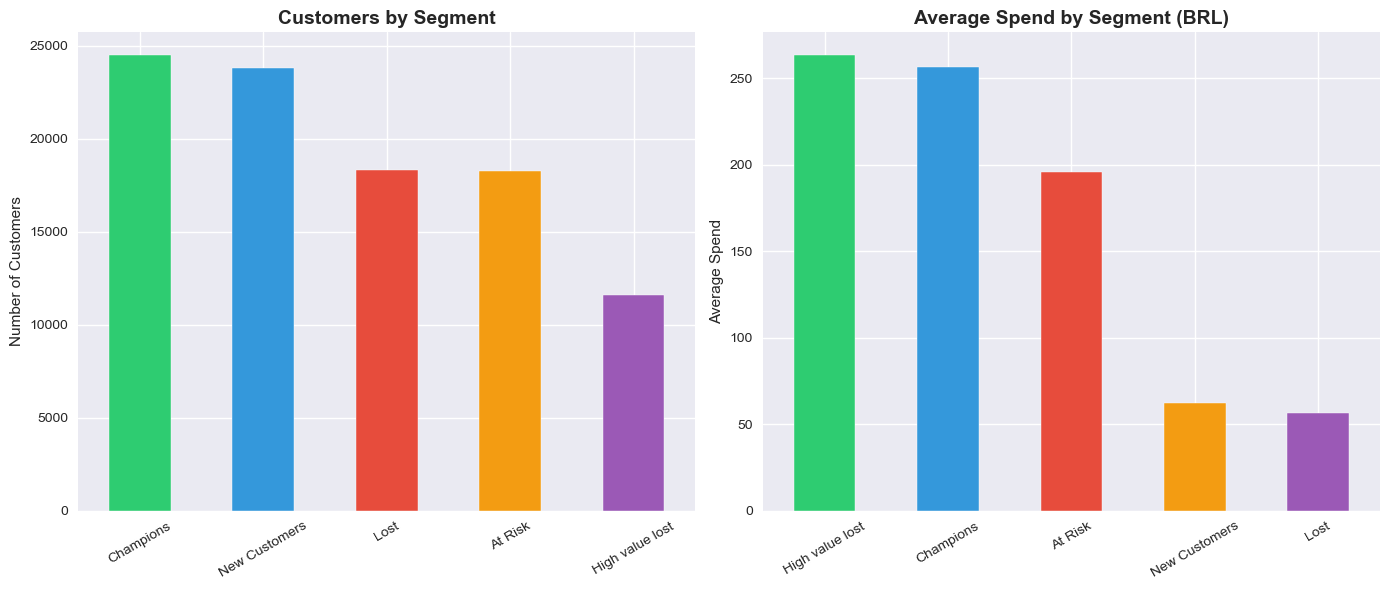

In [21]:
# Gráfico de distribución de segmentos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Cantidad de clientes por segmento
colores = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']
rfm['Segment'].value_counts().plot(
    kind='bar', ax=axes[0], color=colores, edgecolor='white'
)
axes[0].set_title('Customers by Segment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=30)

# Gráfico 2: Gasto promedio por segmento
rfm.groupby('Segment')['monetary'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color=colores, edgecolor='white'
)
axes[1].set_title('Average Spend by Segment (BRL)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Average Spend')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../reports/segmentos_rfm.png', dpi=150, bbox_inches='tight')
plt.show()

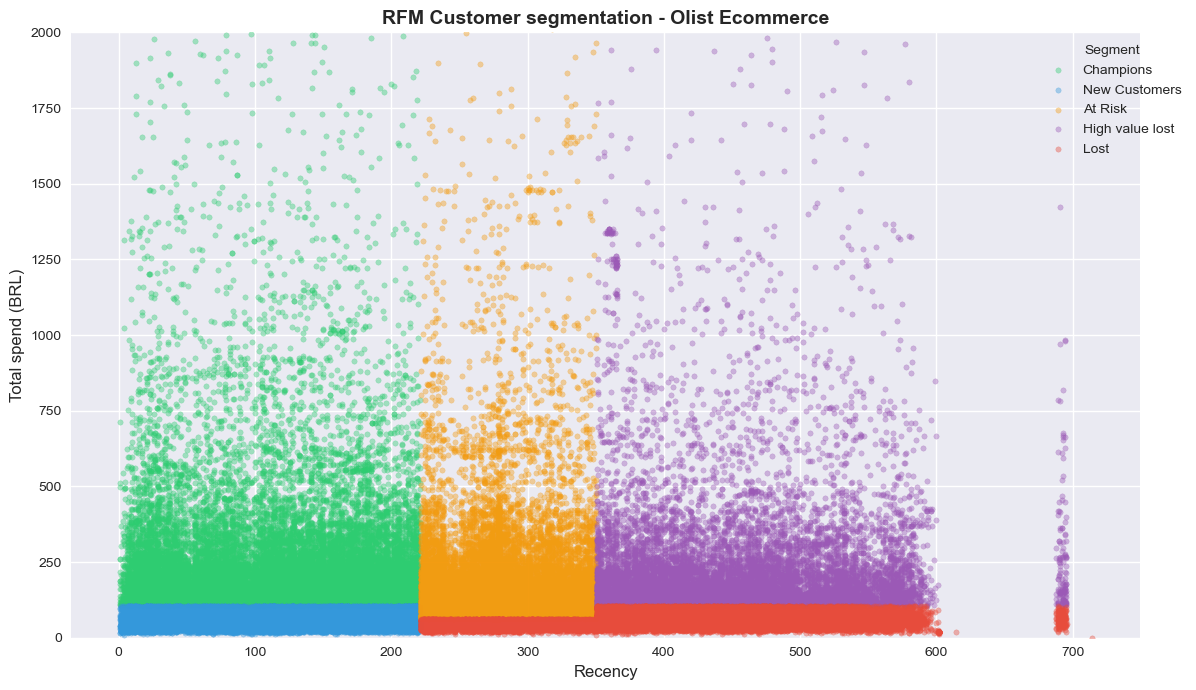

In [22]:
# Scatter plot recency vs monetary by segment
fig, ax = plt.subplots(figsize=(12, 7))

colores_seg = {
    'Champions': '#2ecc71',
    'New Customers': '#3498db', 
    'At Risk': '#f39c12',
    'High value lost': '#9b59b6',
    'Lost': '#e74c3c'
}

for segmento, color in colores_seg.items():
    datos = rfm[rfm['Segment'] == segmento]
    ax.scatter(datos['recency'], datos['monetary'], 
               c=color, label=segmento, alpha=0.4, s=15)

ax.set_xlabel('Recency', fontsize=12)
ax.set_ylabel('Total spend (BRL)', fontsize=12)
ax.set_title('RFM Customer segmentation - Olist Ecommerce', fontsize=14, fontweight='bold')
ax.legend(title='Segment', bbox_to_anchor=(1.05, 1))
ax.set_ylim(0, 2000)  # limitamos para mejor visualización

plt.tight_layout()
plt.savefig('../reports/scatter_rfm.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings and Business Recommendations

25% of customers are Champions — they bought recently and spent well above average.
The most interesting group is High-Value Lost (12%): they spent the most on average(~260 BRL) but haven't come back in over 400 days. These are the customers worth fighting for.

| Segment | Suggested Action | Channel |
|---|---|---|
| Champions | Loyalty rewards, early access to deals | Personalized email |
| New Customers | Upselling, second-purchase coupons | Push notification |
| At Risk | Reactivation campaign with discount | Email + retargeting |
| High-Value Lost | Exclusive high-value offer | Direct email |
| Lost | Exclude from paid campaigns | — |

